# Two-IMU rotating-box simulation

Forward simulation of the BNO08x RVC firmware output (`yaw`, `pitch`,
`roll`, `accel_{x,y,z}`) for the rotating-box geometry, as a function of
the two box DoFs. This is prep for the data-analysis step that will
invert this map on real measurements.

## Geometry

- World frame: `z_w` is up (against gravity).
- The box is suspended along its x-axis. **θ (elevation)** is the
  rotation about world x: `R_box = R_x(θ)`.
- A turntable on top of the box rotates about the box's z-axis by
  **φ (azimuth)**. Because the turntable rides on the box, its
  rotation axis `z'` moves with θ:
  `R_turntable = R_x(θ) · R_z(φ)`.
  Equivalently, `R_x(θ) · R_z(φ) = R_{z'}(φ) · R_x(θ)` with
  `z' = R_x(θ)·ẑ` — i.e. "elevate first, then spin about the new z".

## IMUs

Each IMU has a configurable mount rotation `M` mapping its body frame
into its host frame (box for IMU1, turntable for IMU2):

- IMU1 (in box):       `R₁ = R_x(θ) · M₁`     — sees only θ.
- IMU2 (on turntable): `R₂ = R_x(θ) · R_z(φ) · M₂` — sees both.

## Output convention

The BNO08x in RVC mode reports ZYX intrinsic Tait-Bryan angles plus the
gravity-bearing accelerometer. From `R = R_z(yaw)·R_y(pitch)·R_x(roll)`:

- `pitch = -arcsin(R[2,0])`
- `roll  = atan2(R[2,1], R[2,2])`
- `yaw   = atan2(R[1,0], R[0,0])`

Stationary accel reads the reaction to gravity, `a_body = Rᵀ · [0,0,g]`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

GRAVITY = 9.80665  # m/s^2


## Rotation helpers

In [2]:
def R_x(a):
    a = np.asarray(a, dtype=float)
    c, s = np.cos(a), np.sin(a)
    R = np.zeros(a.shape + (3, 3))
    R[..., 0, 0] = 1
    R[..., 1, 1] = c
    R[..., 1, 2] = -s
    R[..., 2, 1] = s
    R[..., 2, 2] = c
    return R


def R_y(a):
    a = np.asarray(a, dtype=float)
    c, s = np.cos(a), np.sin(a)
    R = np.zeros(a.shape + (3, 3))
    R[..., 0, 0] = c
    R[..., 0, 2] = s
    R[..., 1, 1] = 1
    R[..., 2, 0] = -s
    R[..., 2, 2] = c
    return R


def R_z(a):
    a = np.asarray(a, dtype=float)
    c, s = np.cos(a), np.sin(a)
    R = np.zeros(a.shape + (3, 3))
    R[..., 0, 0] = c
    R[..., 0, 1] = -s
    R[..., 1, 0] = s
    R[..., 1, 1] = c
    R[..., 2, 2] = 1
    return R


def euler_zyx_deg(R):
    """ZYX intrinsic Tait-Bryan extraction from R = Rz(yaw) Ry(pitch) Rx(roll).

    Accepts R of shape (..., 3, 3); returns yaw, pitch, roll arrays in degrees.
    """
    pitch = -np.arcsin(np.clip(R[..., 2, 0], -1.0, 1.0))
    roll = np.arctan2(R[..., 2, 1], R[..., 2, 2])
    yaw = np.arctan2(R[..., 1, 0], R[..., 0, 0])
    return np.degrees(yaw), np.degrees(pitch), np.degrees(roll)


def gravity_in_body(R, g=GRAVITY):
    """a_body = R^T @ [0,0,g]; for R of shape (...,3,3) returns (...,3)."""
    return R[..., 2, :] * g


## Mount specification

`mount_from_spec` maps an IMU body frame into its host frame as a signed
permutation (column k = where IMU body axis k points in the host frame),
optionally followed by a small extra rotation about a host axis to model
fine misalignment.


In [3]:
_AXIS_VEC = {
    "x": np.array([1.0, 0.0, 0.0]),
    "y": np.array([0.0, 1.0, 0.0]),
    "z": np.array([0.0, 0.0, 1.0]),
}
_R_BUILDER = {"x": R_x, "y": R_y, "z": R_z}


def mount_from_spec(axes=("+x", "+y", "+z"), extra_axis="z", extra_deg=0.0):
    """Build a 3x3 mount rotation (body -> host).

    axes[k] tells where IMU body axis k points in the host frame, e.g.
    ("+y","-x","+z") means body x points along host +y, body y along host -x.
    Validated as a signed permutation. extra_deg adds a rotation about
    extra_axis in the host frame, applied after the permutation.
    """
    seen = set()
    P = np.zeros((3, 3))
    for k, spec in enumerate(axes):
        if (
            not isinstance(spec, str)
            or len(spec) != 2
            or spec[0] not in "+-"
            or spec[1] not in "xyz"
        ):
            raise ValueError(
                f"axes[{k}]={spec!r} must be one of +x,-x,+y,-y,+z,-z"
            )
        if spec[1] in seen:
            raise ValueError(f"duplicate axis {spec[1]!r} in axes={axes}")
        seen.add(spec[1])
        sign = 1.0 if spec[0] == "+" else -1.0
        P[:, k] = sign * _AXIS_VEC[spec[1]]
    R_extra = _R_BUILDER[extra_axis](np.radians(extra_deg))
    return P @ R_extra


## Configure the two IMU mounts

Edit the two cells below to match the physical mounting. Defaults are
identity (IMU body frame == host frame).


In [4]:
# IMU1: mounted inside the box. Host frame = box body frame.
M1 = mount_from_spec(axes=("+x", "+y", "+z"), extra_axis="z", extra_deg=0.0)
M1


array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [5]:
# IMU2: mounted on the turntable. Host frame = turntable body frame.
M2 = mount_from_spec(axes=("+x", "+y", "+z"), extra_axis="z", extra_deg=0.0)
M2


array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

## Sweep grid and forward simulation

In [6]:
theta_deg = np.linspace(-90.0, 90.0, 181)   # elevation, about world x
phi_deg   = np.linspace(-180.0, 180.0, 361)  # azimuth, about box z'

theta_rad = np.radians(theta_deg)
phi_rad = np.radians(phi_deg)

R_theta = R_x(theta_rad)  # (Nt, 3, 3)
R_phi   = R_z(phi_rad)    # (Np, 3, 3)

# IMU1: depends only on theta. Broadcast so we have a (Nt, Np, 3, 3) view.
R1_theta = R_theta @ M1                                   # (Nt, 3, 3)
R1 = np.broadcast_to(
    R1_theta[:, None, :, :], (theta_rad.size, phi_rad.size, 3, 3)
)

# IMU2: theta then phi then mount.
R2 = R_theta[:, None, :, :] @ R_phi[None, :, :, :] @ M2   # (Nt, Np, 3, 3)

yaw1, pitch1, roll1 = euler_zyx_deg(R1)
yaw2, pitch2, roll2 = euler_zyx_deg(R2)

a1 = gravity_in_body(R1)  # (Nt, Np, 3)
a2 = gravity_in_body(R2)

print("grid:", yaw1.shape, "accel:", a1.shape)


grid: (181, 361) accel: (181, 361, 3)


## Sanity checks

In [7]:
def _wrap_deg(x):
    """Wrap to (-180, 180]."""
    return ((np.asarray(x) + 180.0) % 360.0) - 180.0


i0 = int(np.argmin(np.abs(theta_deg)))
j0 = int(np.argmin(np.abs(phi_deg)))

# At theta=phi=0 with identity mounts: all-zero angles, accel = (0,0,g).
identity_mounts = np.allclose(M1, np.eye(3)) and np.allclose(M2, np.eye(3))
if identity_mounts:
    assert np.allclose(
        [yaw1[i0, j0], pitch1[i0, j0], roll1[i0, j0]], 0.0, atol=1e-9
    )
    assert np.allclose(
        [yaw2[i0, j0], pitch2[i0, j0], roll2[i0, j0]], 0.0, atol=1e-9
    )
    assert np.allclose(a1[i0, j0], [0.0, 0.0, GRAVITY], atol=1e-9)
    assert np.allclose(a2[i0, j0], [0.0, 0.0, GRAVITY], atol=1e-9)

    # IMU1 must be independent of phi.
    for arr in (yaw1, pitch1, roll1):
        assert np.allclose(arr, arr[:, :1])
    for k in range(3):
        assert np.allclose(a1[..., k], a1[:, :1, k])

    # IMU2 at theta=0: yaw == phi, pitch == roll == 0.
    assert np.allclose(_wrap_deg(yaw2[i0] - phi_deg), 0.0, atol=1e-9)
    assert np.allclose(pitch2[i0], 0.0, atol=1e-9)
    assert np.allclose(roll2[i0], 0.0, atol=1e-9)

# Gravity magnitude is preserved everywhere.
gnorm1 = np.linalg.norm(a1, axis=-1)
gnorm2 = np.linalg.norm(a2, axis=-1)
assert np.allclose(gnorm1, GRAVITY, atol=1e-9)
assert np.allclose(gnorm2, GRAVITY, atol=1e-9)

print(
    "sanity checks passed"
    + (" (identity mounts)" if identity_mounts else " (non-identity mounts: "
       "skipped mount-specific assertions)")
)
print(f"|g| min={gnorm1.min():.9f}  max={gnorm1.max():.9f}")


sanity checks passed (identity mounts)
|g| min=9.806650000  max=9.806650000


## Heatmaps: yaw / pitch / roll over (θ, φ)

Top row IMU1 (box), bottom row IMU2 (turntable). Colour scale is shared
per channel between the two IMUs so they can be compared directly.

Note: `pitch` is bounded to `[-90°, 90°]`; near `|pitch|=90°` `yaw` and
`roll` are gimbal-degenerate and `atan2` will jump.


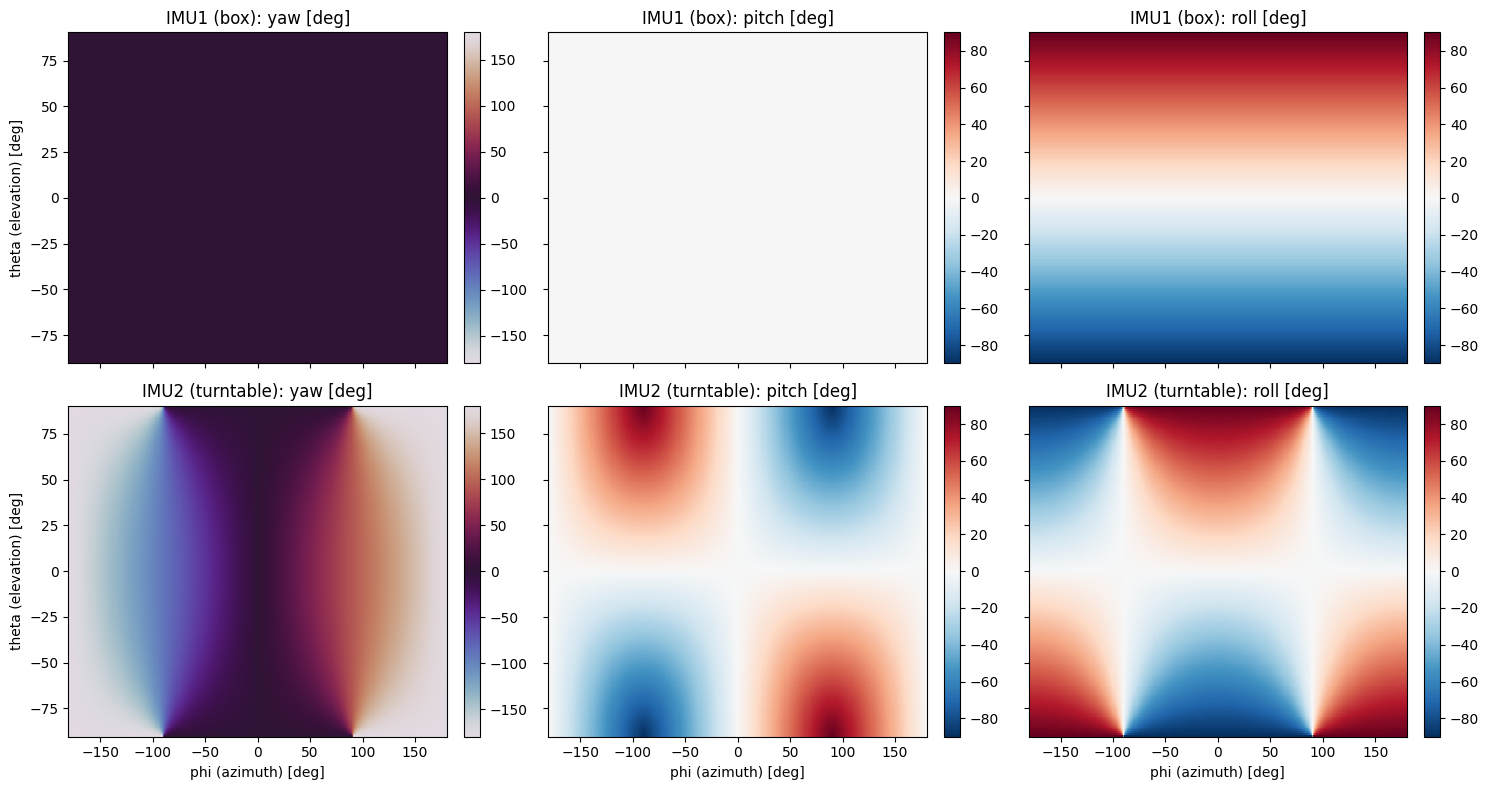

In [8]:
def _plot_euler_heatmaps(yaw1, pitch1, roll1, yaw2, pitch2, roll2,
                            theta_deg, phi_deg):
    channels = [("yaw", yaw1, yaw2, "twilight"),
                ("pitch", pitch1, pitch2, "RdBu_r"),
                ("roll", roll1, roll2, "RdBu_r")]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
    for col, (name, a, b, cmap) in enumerate(channels):
        vmin = float(min(a.min(), b.min()))
        vmax = float(max(a.max(), b.max()))
        if cmap == "RdBu_r":
            vlim = max(abs(vmin), abs(vmax))
            vmin, vmax = -vlim, vlim
        for row, (data, label) in enumerate(
            [(a, "IMU1 (box)"), (b, "IMU2 (turntable)")]
        ):
            ax = axes[row, col]
            m = ax.pcolormesh(
                phi_deg, theta_deg, data,
                vmin=vmin, vmax=vmax, cmap=cmap, shading="auto",
            )
            ax.set_title(f"{label}: {name} [deg]")
            if row == 1:
                ax.set_xlabel("phi (azimuth) [deg]")
            if col == 0:
                ax.set_ylabel("theta (elevation) [deg]")
            fig.colorbar(m, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    return fig


_plot_euler_heatmaps(
    yaw1, pitch1, roll1, yaw2, pitch2, roll2, theta_deg, phi_deg
)
plt.show()


## 1D slices

Fix one angle, sweep the other. Lets you read off the functional form of
each Euler channel.


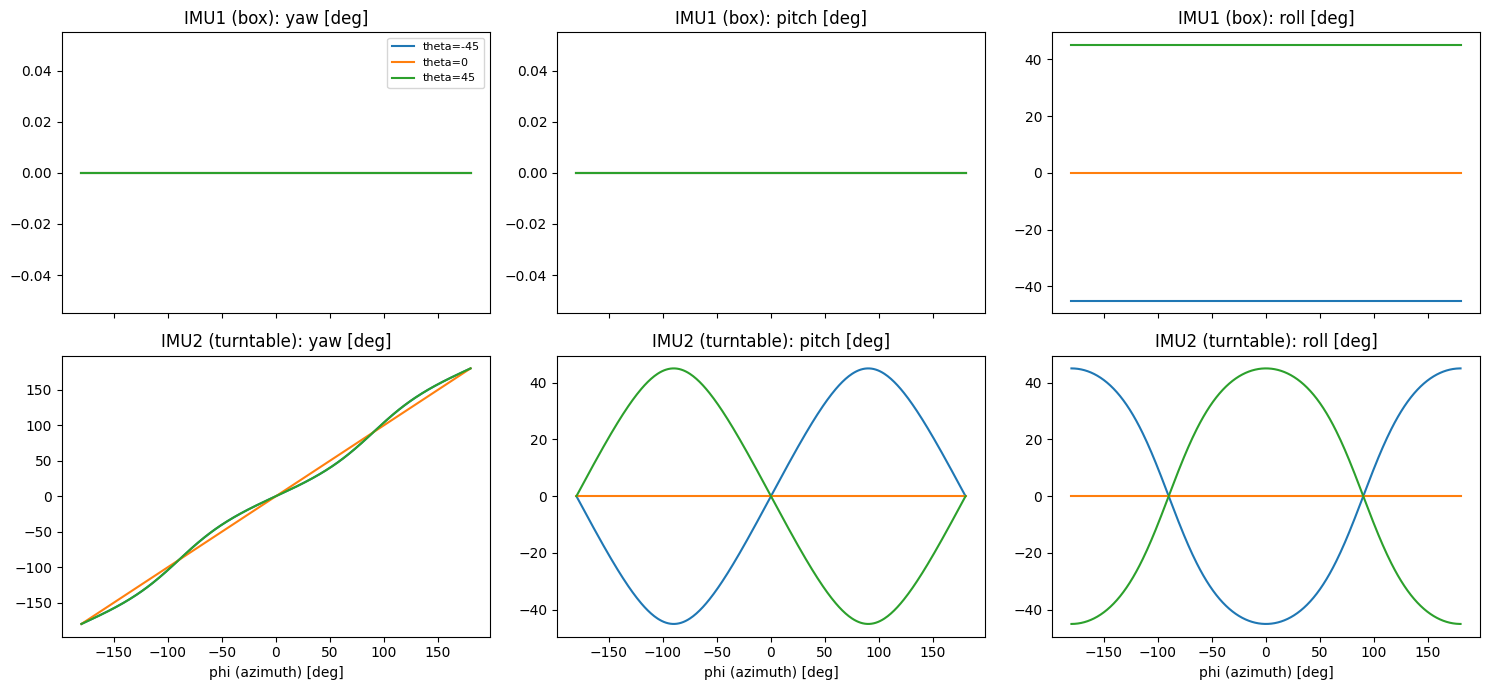

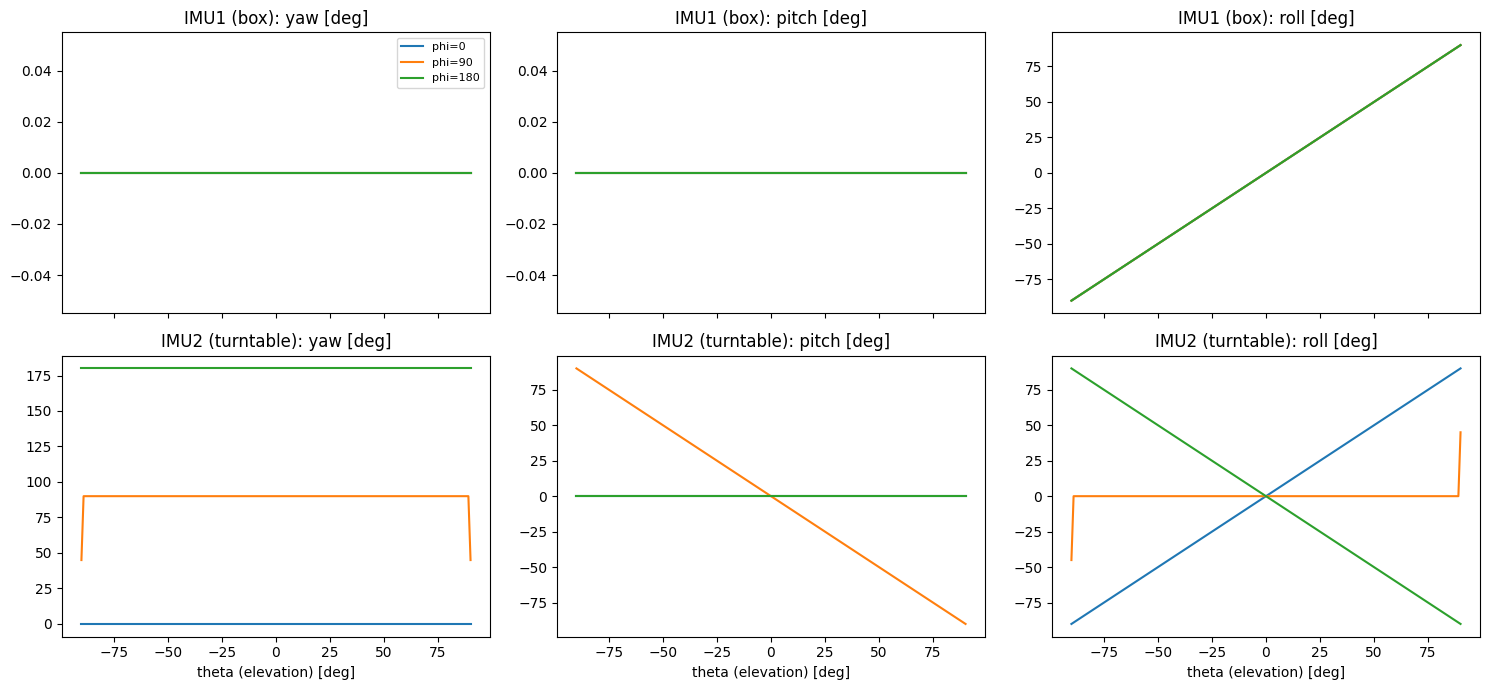

In [9]:
def _nearest_index(arr, value):
    return int(np.argmin(np.abs(arr - value)))


def _plot_slices_fixed_theta(thetas_deg=(-45.0, 0.0, 45.0)):
    fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
    panels = [("yaw", yaw1, yaw2),
              ("pitch", pitch1, pitch2),
              ("roll", roll1, roll2)]
    for t in thetas_deg:
        i = _nearest_index(theta_deg, t)
        for col, (name, d1, d2) in enumerate(panels):
            axes[0, col].plot(phi_deg, d1[i], label=f"theta={theta_deg[i]:.0f}")
            axes[1, col].plot(phi_deg, d2[i], label=f"theta={theta_deg[i]:.0f}")
    for col, (name, _, _) in enumerate(panels):
        axes[0, col].set_title(f"IMU1 (box): {name} [deg]")
        axes[1, col].set_title(f"IMU2 (turntable): {name} [deg]")
        axes[1, col].set_xlabel("phi (azimuth) [deg]")
    axes[0, 0].legend(loc="best", fontsize=8)
    fig.tight_layout()
    return fig


def _plot_slices_fixed_phi(phis_deg=(0.0, 90.0, 180.0)):
    fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
    panels = [("yaw", yaw1, yaw2),
              ("pitch", pitch1, pitch2),
              ("roll", roll1, roll2)]
    for p in phis_deg:
        j = _nearest_index(phi_deg, p)
        for col, (name, d1, d2) in enumerate(panels):
            axes[0, col].plot(theta_deg, d1[:, j], label=f"phi={phi_deg[j]:.0f}")
            axes[1, col].plot(theta_deg, d2[:, j], label=f"phi={phi_deg[j]:.0f}")
    for col, (name, _, _) in enumerate(panels):
        axes[0, col].set_title(f"IMU1 (box): {name} [deg]")
        axes[1, col].set_title(f"IMU2 (turntable): {name} [deg]")
        axes[1, col].set_xlabel("theta (elevation) [deg]")
    axes[0, 0].legend(loc="best", fontsize=8)
    fig.tight_layout()
    return fig


_plot_slices_fixed_theta()
_plot_slices_fixed_phi()
plt.show()


## Accelerometer (gravity-only) over (θ, φ)

What the BNO08x reports for `accel_{x,y,z}` when the box is held
stationary at each (θ, φ). Independent cross-check on the orientation
math: gravity magnitude must stay at `g` everywhere.


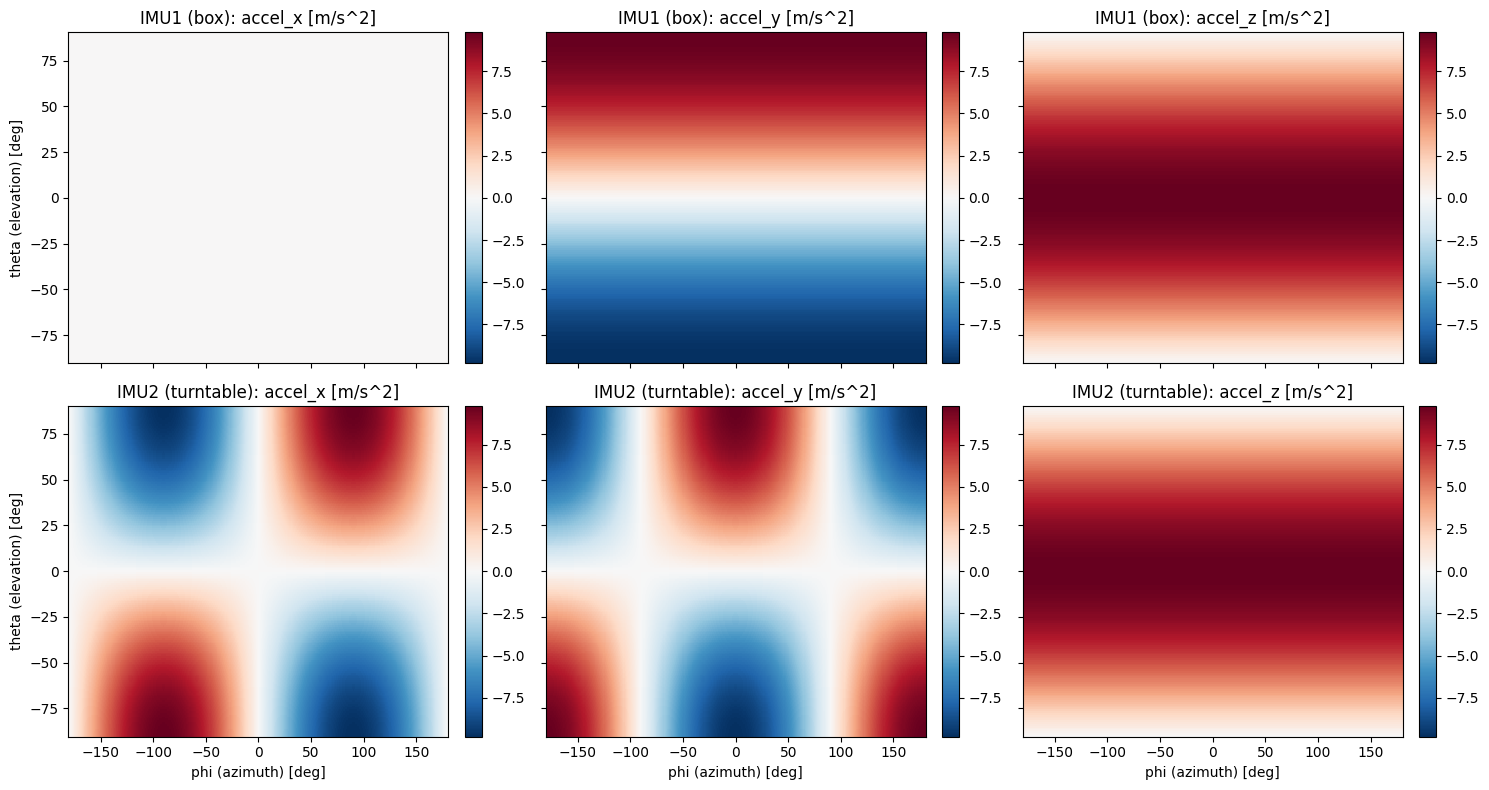

In [10]:
def _plot_accel_heatmaps():
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
    labels = ["accel_x", "accel_y", "accel_z"]
    for col, label in enumerate(labels):
        a = a1[..., col]
        b = a2[..., col]
        vlim = float(max(np.abs(a).max(), np.abs(b).max()))
        for row, (data, who) in enumerate(
            [(a, "IMU1 (box)"), (b, "IMU2 (turntable)")]
        ):
            ax = axes[row, col]
            m = ax.pcolormesh(
                phi_deg, theta_deg, data,
                vmin=-vlim, vmax=vlim, cmap="RdBu_r", shading="auto",
            )
            ax.set_title(f"{who}: {label} [m/s^2]")
            if row == 1:
                ax.set_xlabel("phi (azimuth) [deg]")
            if col == 0:
                ax.set_ylabel("theta (elevation) [deg]")
            fig.colorbar(m, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    return fig


_plot_accel_heatmaps()
plt.show()


## Notes for the analysis step

- The forward map `(θ, φ, M₁, M₂) → (yaw, pitch, roll, accel)` is what
  the BNO08x reports in RVC mode. The analysis step is the inverse:
  recover `(θ, φ)` (and, with enough orientations, `M₁, M₂`) from
  measured streams.
- **Use the accel triplet as the primary observable.** It is
  gravity-only (in the regime below), has `|aᵇ| = g` everywhere, and is
  a continuous function of `R` with no parametrization singularities.
  IMU1's accel constrains θ alone (it is φ-independent); IMU2's accel
  adds φ. The Euler channels are a diagnostic cross-check, not a
  primary observable.
- **Motion regime.** The accelerometer measures specific force, i.e.
  gravity reaction *plus* any linear acceleration of the IMU. At the
  operational scan rate (~2 min per azimuth rotation, single motor at a
  time, ω ≈ 0.05 rad/s), centripetal `ω²·r` is ≲ 0.3 mg out to r=1 m —
  well below the BNO08x accel noise floor (~0.5–1 mg RMS). The accel
  inverse is therefore valid *continuously* during the scan, not only
  at rest; no stationarity gating is needed in steady state. Ramp
  transients at motor start/stop add a few mg tangentially for a sample
  or two — exclude those windows if precision matters.
- The Euler channels degrade in two ways the accel does not:
  - Yaw drifts (BNO08x mag/init).
  - At `|pitch| → 90°` the ZYX (yaw, roll) decomposition is degenerate
    — only their combination is observable from `R`, so the chip's
    output there reflects an internal tiebreaker, not a knowledge gap.
    The chip's quaternion is fine through the singularity, but RVC
    does not ship it, so we cannot use it directly.
- The accel inverse has its own degeneracy: when `θ ≈ 0` the gravity
  vector lies along the turntable's rotation axis and φ is unobservable
  — physical, not numerical. Sensitivity scales as `g·|sin θ|`, so
  practical φ recovery wants `|θ|` at least a few degrees. At/near
  θ=0, fall back to IMU2's yaw (which equals φ when M₂=I and θ=0,
  modulo BNO yaw drift) or interpolate across the transit.


## Inference: recover (θ, φ) from accel

Closed-form inverse of the gravity-only forward model. With known mount
rotations `M₁`, `M₂`, the gravity vector in each IMU's *host* frame is
`Mₖ · aₖ`. From IMU1 (in the box):

- `M₁ · a₁ = R_x(θ)ᵀ · [0,0,g] = [0, g·sin(θ), g·cos(θ)]`
- `θ̂ = atan2((M₁·a₁)_y, (M₁·a₁)_z)` — unambiguous on `(-π, π]`.

From IMU2 (on the turntable), with θ̂ in hand:

- `M₂ · a₂ = R_z(φ)ᵀ · [0, g·sin(θ), g·cos(θ)] = [g·sφ·sθ, g·cφ·sθ, g·cθ]`
- `φ̂ = atan2(s · (M₂·a₂)_x, s · (M₂·a₂)_y)` with `s = sign(sin(θ̂))`.

The `sign(sin(θ̂))` factor is needed because `sin(θ)` enters both
`atan2` arguments multiplicatively: a negative `sin(θ)` would otherwise
fold the recovered φ by 180°. φ is undefined at `sin(θ) = 0`.


In [ ]:
def estimate_theta_phi_from_accel(a1, a2, M1=np.eye(3), M2=np.eye(3)):
    """Closed-form (theta, phi) from the two IMU gravity vectors.

    Forward model assumed:
        a1 = M1.T @ R_x(theta).T @ [0, 0, g]
        a2 = M2.T @ R_z(phi).T @ R_x(theta).T @ [0, 0, g]

    Returns (theta_deg, phi_deg) with the same leading shape as a1, a2.
    phi is degenerate where sin(theta) -> 0 (gravity along the turntable
    rotation axis); flag those points externally if needed.
    """
    g_box = np.einsum("ij,...j->...i", M1, a1)
    g_tt = np.einsum("ij,...j->...i", M2, a2)
    theta = np.arctan2(g_box[..., 1], g_box[..., 2])
    sin_t = np.sin(theta)
    s = np.where(sin_t >= 0.0, 1.0, -1.0)
    phi = np.arctan2(s * g_tt[..., 0], s * g_tt[..., 1])
    return np.degrees(theta), np.degrees(phi)


theta_hat, phi_hat = estimate_theta_phi_from_accel(a1, a2, M1, M2)

theta_truth = theta_deg[:, None]
phi_truth = phi_deg[None, :]
theta_err = theta_hat - theta_truth
phi_err = _wrap_deg(phi_hat - phi_truth)

phi_observable = np.abs(np.sin(np.radians(theta_truth))) > 1e-6
phi_err_obs = phi_err[np.broadcast_to(phi_observable, phi_err.shape)]

print(f"theta residual: max |err| = {np.abs(theta_err).max():.3e} deg")
print(f"phi residual (theta != 0): max |err| = {np.abs(phi_err_obs).max():.3e} deg")


### Residual heatmaps

At machine precision everywhere except the `θ = 0` row, where φ is
unobservable from accel alone. That row is masked so it does not blow
out the colour scale.


In [ ]:
def _plot_inference_residuals():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

    vlim_t = max(float(np.abs(theta_err).max()), 1e-12)
    m = axes[0].pcolormesh(
        phi_deg, theta_deg, theta_err,
        vmin=-vlim_t, vmax=vlim_t, cmap="RdBu_r", shading="auto",
    )
    axes[0].set_title("theta_hat - theta [deg]")
    axes[0].set_xlabel("phi (azimuth) [deg]")
    axes[0].set_ylabel("theta (elevation) [deg]")
    fig.colorbar(m, ax=axes[0], fraction=0.046, pad=0.04)

    phi_err_plot = np.where(
        np.broadcast_to(phi_observable, phi_err.shape), phi_err, np.nan
    )
    finite = phi_err_plot[np.isfinite(phi_err_plot)]
    vlim_p = max(float(np.abs(finite).max()) if finite.size else 1e-12, 1e-12)
    m = axes[1].pcolormesh(
        phi_deg, theta_deg, phi_err_plot,
        vmin=-vlim_p, vmax=vlim_p, cmap="RdBu_r", shading="auto",
    )
    axes[1].set_title("phi_hat - phi [deg]  (theta=0 row masked)")
    axes[1].set_xlabel("phi (azimuth) [deg]")
    fig.colorbar(m, ax=axes[1], fraction=0.046, pad=0.04)
    fig.tight_layout()
    return fig


_plot_inference_residuals()
plt.show()


## Recovery phases: accel vs yaw fallback

Two regimes for φ recovery, with a regime-determined switch:

- **Accel regime** (`|sin θ|` not small): φ from
  `atan2((M₂·a₂)_x, (M₂·a₂)_y)`, sign-corrected. Drift-free, but the
  in-plane signal scales as `g·|sin θ|` so noise blows up near θ=0:
  `σ_φ_accel ≈ σ_a / (g·|sin θ|)`.
- **Yaw regime** (small `|θ|`): with `M₂=I`, the ZYX yaw of `R₂` equals
  φ exactly at θ=0 and to O(θ²) for small θ. Geometry-free, but
  inherits the BNO RVC yaw drift: `σ_φ_yaw ≈ σ_yaw_drift` independent
  of θ.

The two error curves cross at `|sin θ_cross| = (σ_a/g) / σ_yaw_rad`. For
the BNO numbers below (σ_a ≈ 1 mg, σ_yaw_drift ≈ 2°) that's
`|θ_cross| ≈ 1.6°`. Outside ±θ_cross use accel; inside, fall back to
yaw₂.


In [ ]:
SIGMA_ACCEL_MG = 1.0   # BNO085 accel noise floor, RMS
SIGMA_YAW_DEG = 2.0    # BNO RVC yaw drift envelope (rough, tune to your hw)

sigma_a = SIGMA_ACCEL_MG * 1e-3 * GRAVITY
sin_theta_cross = (sigma_a / GRAVITY) / np.radians(SIGMA_YAW_DEG)
theta_cross_deg = np.degrees(np.arcsin(np.clip(sin_theta_cross, 0.0, 1.0)))
print(f"crossover: |theta| = {theta_cross_deg:.2f} deg "
      f"(|sin theta| = {sin_theta_cross:.4f})")


def _plot_phi_uncertainty():
    th = np.linspace(-90, 90, 1801)
    sigma_phi_accel = np.degrees(
        (sigma_a / GRAVITY)
        / np.maximum(np.abs(np.sin(np.radians(th))), 1e-12)
    )
    sigma_phi_yaw = np.full_like(th, SIGMA_YAW_DEG)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.semilogy(th, sigma_phi_accel,
                label=fr"accel inverse  $\sigma_a$={SIGMA_ACCEL_MG} mg")
    ax.semilogy(th, sigma_phi_yaw,
                label=fr"yaw$_2$ fallback  $\sigma_\mathrm{{yaw}}$={SIGMA_YAW_DEG}$^\circ$")
    for x in (-theta_cross_deg, theta_cross_deg):
        ax.axvline(x, color="k", ls="--", lw=1)
    ax.axvspan(-theta_cross_deg, theta_cross_deg, alpha=0.12, color="C1",
               label=fr"yaw regime (|theta| < {theta_cross_deg:.2f}$^\circ$)")
    ax.set_xlabel("theta [deg]")
    ax.set_ylabel(r"$\sigma_\phi$ [deg]")
    ax.set_ylim(1e-2, 1e2)
    ax.set_title("phi uncertainty vs theta — regime crossover")
    ax.legend(loc="upper center")
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
    return fig


_plot_phi_uncertainty()
plt.show()


### Worked example: trajectory through θ=0

Synthetic time series with `θ` swinging through zero and a constant
true φ. Realistic accel noise on both IMUs and a slow sinusoidal yaw
drift on IMU2. The merged estimator picks accel outside ±θ_cross and
yaw₂ inside it; horizontal lines on the θ panel mark the regime
boundary, and the regime-decision band is shaded on the φ panel.


In [ ]:
def _simulate_trajectory(N=2000, theta_amp_deg=30.0, phi_true_deg=60.0,
                          seed=0):
    t = np.arange(N)
    theta_traj = theta_amp_deg * np.sin(2 * np.pi * t / N)
    phi_truth_arr = phi_true_deg * np.ones(N)

    theta_rad = np.radians(theta_traj)
    phi_rad = np.radians(phi_truth_arr)
    R1_ts = R_x(theta_rad) @ M1
    R2_ts = R_x(theta_rad) @ R_z(phi_rad) @ M2
    a1_clean = R1_ts[..., 2, :] * GRAVITY
    a2_clean = R2_ts[..., 2, :] * GRAVITY

    rng = np.random.default_rng(seed)
    a1_meas = a1_clean + rng.normal(0, sigma_a, a1_clean.shape)
    a2_meas = a2_clean + rng.normal(0, sigma_a, a2_clean.shape)

    yaw2_clean = np.degrees(
        np.arctan2(R2_ts[..., 1, 0], R2_ts[..., 0, 0])
    )
    yaw_drift = SIGMA_YAW_DEG * np.sin(2 * np.pi * t / (4 * N))

    return t, theta_traj, phi_truth_arr, a1_meas, a2_meas, yaw2_clean + yaw_drift


t_arr, theta_true, phi_true_arr, a1_ts, a2_ts, phi_yaw_meas = _simulate_trajectory()

theta_hat_ts, phi_hat_accel_ts = estimate_theta_phi_from_accel(
    a1_ts, a2_ts, M1, M2
)
sin_theta_hat = np.sin(np.radians(theta_hat_ts))
use_accel = np.abs(sin_theta_hat) > sin_theta_cross
phi_hat_ts = np.where(use_accel, phi_hat_accel_ts, phi_yaw_meas)


def _rmse(x):
    return float(np.sqrt(np.mean(np.asarray(x) ** 2)))


print(f"phi RMSE  accel-only: {_rmse(phi_hat_accel_ts - phi_true_arr):.3f} deg")
print(f"phi RMSE  yaw-only  : {_rmse(phi_yaw_meas - phi_true_arr):.3f} deg")
print(f"phi RMSE  merged    : {_rmse(phi_hat_ts - phi_true_arr):.3f} deg")
print(f"yaw-regime samples  : {int((~use_accel).sum())} / {len(t_arr)}")


def _plot_recovery_trace():
    fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

    ax = axes[0]
    ax.plot(t_arr, theta_true, label="theta truth", color="k", lw=1)
    ax.axhline( theta_cross_deg, color="C3", ls="--", lw=1,
                label=fr"$\pm\theta_\mathrm{{cross}}$ = {theta_cross_deg:.2f}$^\circ$")
    ax.axhline(-theta_cross_deg, color="C3", ls="--", lw=1)
    ax.fill_between(t_arr, -theta_cross_deg, theta_cross_deg,
                     where=~use_accel, color="C1", alpha=0.25,
                     label="yaw regime active", step="mid")
    ax.set_ylabel("theta [deg]")
    ax.set_title("Phase: theta trajectory and regime gate")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(t_arr, phi_hat_accel_ts, color="C0", alpha=0.5, lw=0.7,
            label="phi from accel")
    ax.plot(t_arr, phi_yaw_meas, color="C2", alpha=0.7, lw=0.9,
            label="phi from yaw$_2$")
    ax.plot(t_arr, phi_hat_ts, color="k", lw=1.0, label="phi merged")
    ax.axhline(phi_true_arr[0], color="r", ls=":", lw=1,
                label="phi truth")
    # Shade the active-yaw windows for visual continuity with top panel.
    ymin, ymax = (phi_hat_accel_ts.min() - 5, phi_hat_accel_ts.max() + 5)
    ax.fill_between(t_arr, ymin, ymax,
                     where=~use_accel, color="C1", alpha=0.15, step="mid")
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("sample")
    ax.set_ylabel("phi [deg]")
    ax.set_title("Recovered phi: accel vs yaw vs merged")
    ax.legend(loc="upper right", fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    return fig


_plot_recovery_trace()
plt.show()
